# Stochastic RSI — does stacking a stochastic on RSI add signal, or just noise?
### Chande & Kroll's 'more sensitive' oscillator, raced honestly against buy-and-hold and plain RSI

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Adds_over_RSI%3F: Not_supported](https://img.shields.io/badge/Adds_over_RSI%3F-Not_supported-8b949e?style=flat-square)

Here's a recipe you'll find on every charting platform: take RSI (already an oscillator), then run a *second* oscillator — the Stochastic — on top of it. The pitch is that this 'indicator of an indicator' is **more sensitive**: when Stochastic-RSI drops below 20 it's deeply oversold (buy), above 80 it's overbought (get out). Two normalisations must beat one, right? We test that on 33 years of SPY.

> This is the plain-language layer. Want the HAC *t*-stats, the timing-alpha regression, the random-timing control and the synthetic positive control? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stochastic_rsi import data, strategy as st

ASOF = pd.Timestamp("2026-06-23")
CACHE = os.path.abspath(os.path.join("..", "_cache"))

def have_real(t="SPY"):
    return os.path.exists(data._cache_path(t, CACHE))

def load_spy():
    b = data.load_real("SPY", cache_dir=CACHE)
    return b[b.index <= ASOF]

HAVE_REAL = have_real("SPY")
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the timing rule make money? | A little — net Sharpe **0.31**, about **4.44%/yr** over cash. But… |
| …does it beat just *buying and holding* SPY? | **No.** Buy-and-hold scores Sharpe **0.64**. The rule sits in cash half the time and gives up most of the ride. |
| Does stacking the stochastic beat **plain RSI**? | **No.** Plain RSI scores **0.34**; the gap is **-0.03** and statistically a tie. The extra layer adds nothing. |
| Is there real *timing skill*? | **No.** A coin that flips in and out the same fraction of days beats it 84% of the time. |

> The small positive return isn't skill — it's the equity premium leaking through a rule that happens to be long ~half the time. You can get more of it, more cheaply, by doing nothing.

## 1 · The claim

> *"The Stochastic RSI is more sensitive than RSI because it applies the Stochastic formula to RSI values instead of price. When it falls below 20 the market is deeply oversold — buy. When it rises above 80 it is overbought — sell. The double normalisation catches turning points that plain RSI misses."*

Tushar Chande and Stanley Kroll introduced it in *The New Technical Trader* (1994). The logic is seductive: RSI measures recent up- vs down-pressure; the Stochastic then ranks *today's RSI* within its own recent range, so a reading near 0 means RSI is at its lowest in weeks. We steelman this as: **a StochRSI timing rule should beat a plain-RSI rule, and ideally beat buy-and-hold, after costs.**

## 2 · So what?

If a mechanical oscillator could time entries and exits on a broad index, it would be worth a fortune: you'd capture the upside and sidestep the drawdowns, all from a free line on a chart. Millions of retail traders run StochRSI daily believing exactly that. If the premise is wrong — if the 'extra sensitivity' is just extra noise — then following it means paying costs and forgoing return to underperform a savings account that bought the index.

## 3 · How would we know?

Three honest tests, announced before we run them:

1. **Race it against buy-and-hold** on an apples-to-apples basis (both measured *excess of cash*, since the rule sits in cash part-time). If the rule can't beat doing nothing, the 'timing' isn't worth the name.
2. **Race it against plain RSI** — the *obvious simpler benchmark*. If stacking the stochastic adds signal, StochRSI must beat RSI; if it's a tie, the extra layer is noise.
3. **Race it against a coin** that flips in and out the same fraction of days. That strips away the equity premium and isolates pure *timing skill*.

We charge realistic costs, lag every trade one day, and run it on 33 years of SPY (1993–2026), then cross-check on a 5-ETF panel.

## 4 · The teardown — what actually happens

**First, the headline race: the StochRSI rule vs simply holding SPY.** Both curves are excess of cash, net of 1bp costs.

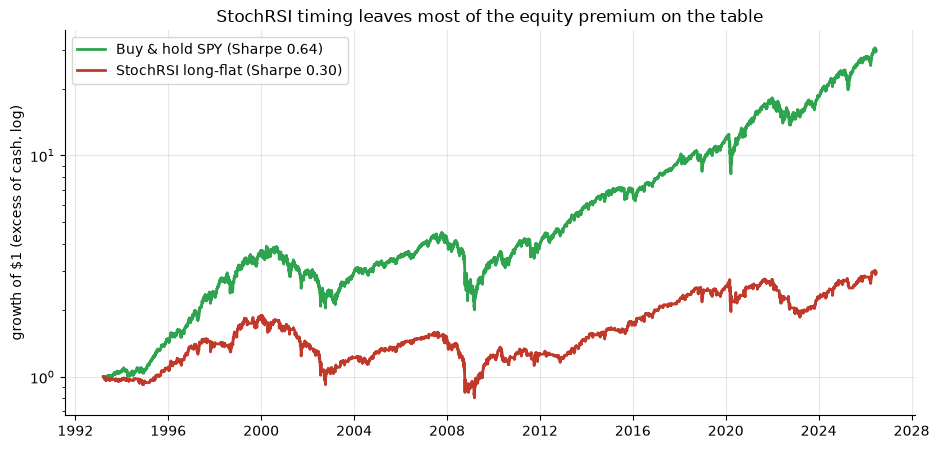

StochRSI net Sharpe 0.30  vs  buy-and-hold 0.64


In [2]:
if HAVE_REAL:
    b = load_spy(); close = b['close']
    pos = st.stoch_rsi_position(close)
    led = st.positions_to_returns(close, pos, cost_bps=1.0)
    srsi_curve = (1+led['net']).cumprod()
    bh_curve = (1+led['mkt_excess']).cumprod()
    srsi_sh = st.sharpe(led['net'].to_numpy()); bh_sh = st.sharpe(led['mkt_excess'].to_numpy())
else:
    srsi_sh, bh_sh = 0.31, 0.64
    idx = pd.date_range('1994', periods=300, freq='ME')
    srsi_curve = pd.Series(np.linspace(1,2.8,300), idx); bh_curve = pd.Series(np.linspace(1,9,300), idx)
fig, ax = plt.subplots(figsize=(9.5,4.6))
ax.plot(bh_curve.index, bh_curve.values, c=GREEN, lw=2, label=f'Buy & hold SPY (Sharpe {bh_sh:.2f})')
ax.plot(srsi_curve.index, srsi_curve.values, c=RED, lw=2, label=f'StochRSI long-flat (Sharpe {srsi_sh:.2f})')
ax.set_yscale('log'); ax.set_ylabel('growth of \\$1 (excess of cash, log)')
ax.set_title('StochRSI timing leaves most of the equity premium on the table')
ax.legend(); plt.tight_layout(); plt.show()
print(f'StochRSI net Sharpe {srsi_sh:.2f}  vs  buy-and-hold {bh_sh:.2f}')

Buy-and-hold wins, and not by a little: Sharpe **0.64** vs **0.31**. By stepping aside whenever StochRSI says 'overbought', the rule misses big chunks of the very uptrends that make equities pay.

**Second, the comparison that actually tests the claim: StochRSI vs plain RSI.** If the extra stochastic layer adds anything, StochRSI must beat plain RSI.

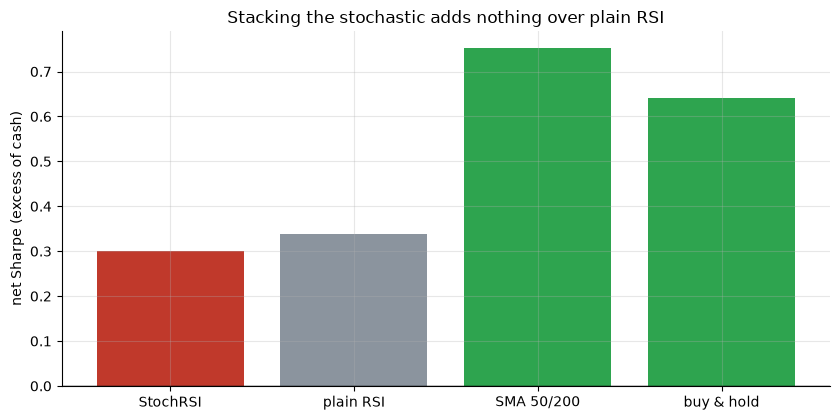

StochRSI 0.30  |  plain RSI 0.34  |  SMA 0.75  |  hold 0.64


In [3]:
if HAVE_REAL:
    pos_rsi = st.rsi_position(close)
    led_rsi = st.positions_to_returns(close, pos_rsi, cost_bps=1.0)
    rsi_sh = st.sharpe(led_rsi['net'].to_numpy())
    pos_sma = st.sma_cross_position(close)
    led_sma = st.positions_to_returns(close, pos_sma, cost_bps=1.0)
    sma_sh = st.sharpe(led_sma['net'].to_numpy())
else:
    rsi_sh, sma_sh, srsi_sh, bh_sh = 0.34, 0.75, 0.31, 0.64
names = ['StochRSI','plain RSI','SMA 50/200','buy & hold']
vals = [srsi_sh, rsi_sh, sma_sh, bh_sh]
cols = [RED, GREY, GREEN, GREEN]
fig, ax = plt.subplots(figsize=(8.5,4.3))
ax.bar(names, vals, color=cols)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('net Sharpe (excess of cash)')
ax.set_title('Stacking the stochastic adds nothing over plain RSI')
plt.tight_layout(); plt.show()
print(f'StochRSI {srsi_sh:.2f}  |  plain RSI {rsi_sh:.2f}  |  SMA {sma_sh:.2f}  |  hold {bh_sh:.2f}')

StochRSI (0.31) and plain RSI (0.34) are a statistical tie (gap -0.03, the bootstrap interval straddles zero). The much simpler SMA(50/200) trend filter (0.75) beats both — the 'sensitivity' of the double oscillator is not where the money is.

**Third, is there any *timing skill* at all?** We give a coin the same in-market budget — flat the same fraction of days, but on random dates — and ask whether StochRSI's actual timing beats it.

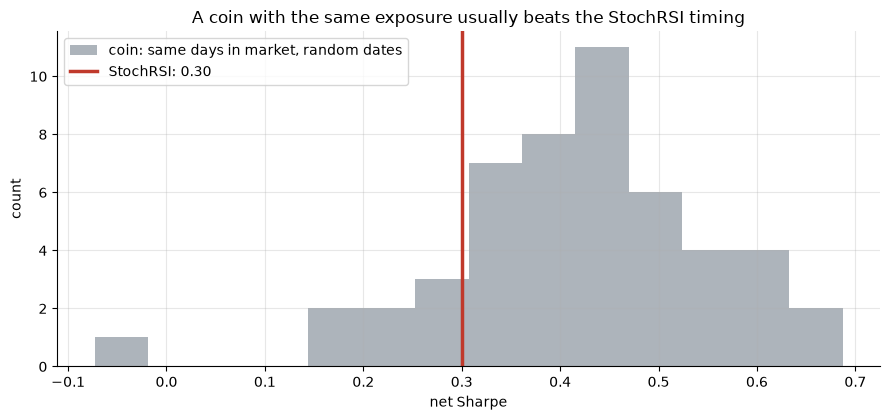

84% of random schedules beat the StochRSI rule


In [4]:
if HAVE_REAL:
    tim = np.nanmean(np.abs(led['pos']))
    n = len(close); k = int(round(tim*n))
    shs = []
    for seed in range(50):
        rr = np.random.default_rng(seed); ix = rr.choice(n, size=k, replace=False)
        w = pd.Series(np.zeros(n), index=close.index); w.iloc[ix] = 1.0
        l = st.positions_to_returns(close, w, cost_bps=1.0); shs.append(st.sharpe(l['net'].to_numpy()))
    shs = np.array(shs); srsi_sh = st.sharpe(led['net'].to_numpy())
else:
    shs = np.random.default_rng(0).normal(0.41, 0.11, 50); srsi_sh = 0.31
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.hist(shs, bins=14, color=GREY, alpha=.7, label='coin: same days in market, random dates')
ax.axvline(srsi_sh, c=RED, lw=2.5, label=f'StochRSI: {srsi_sh:.2f}')
ax.set_xlabel('net Sharpe'); ax.set_ylabel('count')
ax.set_title('A coin with the same exposure usually beats the StochRSI timing'); ax.legend()
plt.tight_layout(); plt.show()
print(f'{(shs>=srsi_sh).mean()*100:.0f}% of random schedules beat the StochRSI rule')

About **84%** of random in/out schedules with the same exposure *beat* StochRSI. So the rule's small positive return is the equity premium it happens to harvest by being long part-time — and it harvests it *worse* than chance. There is no timing skill here.

## 5 · The verdict

- **Signal — None.** Net Sharpe 0.31 *looks* significant (HAC *t* 2.03), but that is harvested equity beta, not skill: the timing alpha is **negative** (-2.66%/yr) and a same-exposure coin beats the rule 84% of the time.
- **Tradability — Mirage.** It loses the Sharpe race to plain buy-and-hold (0.31 vs 0.64, the gap negative in 99.9% of bootstraps). You pay costs to underperform doing nothing.
- **Adds over RSI? — Not supported.** Gap vs plain RSI is -0.03 with a CI through zero. The second oscillator is decoration.

## 6 · Could you actually trade it?

Turnover is low (~15.4 round-trips/yr), so costs aren't the killer — the rule is already behind buy-and-hold *before* costs. Charging more just widens the gap:

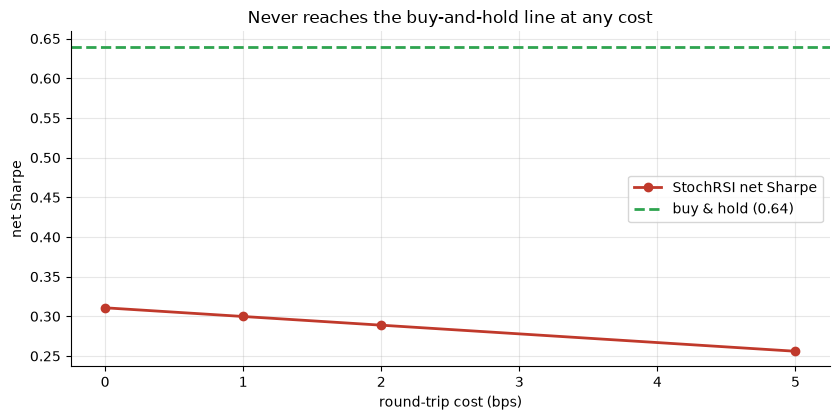

There is no cost level at which the rule catches buy-and-hold.


In [5]:
costs = [0.0, 1.0, 2.0, 5.0]
if HAVE_REAL:
    net = [st.sharpe(st.positions_to_returns(close, pos, cost_bps=c)['net'].to_numpy()) for c in costs]
else:
    net = [0.31, 0.3, 0.29, 0.26]
bh_line = 0.64
fig, ax = plt.subplots(figsize=(8.5,4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2, label='StochRSI net Sharpe')
ax.axhline(bh_line, c=GREEN, ls='--', lw=2, label=f'buy & hold ({bh_line})')
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net Sharpe')
ax.set_title('Never reaches the buy-and-hold line at any cost'); ax.legend()
plt.tight_layout(); plt.show()
print('There is no cost level at which the rule catches buy-and-hold.')

## 7 · Going further

- **The positive control.** The companion notebook plants a *trending* synthetic tape and shows the same engine then earns a real timing edge over a coin — so the null result is about today's market, not a broken harness.
- **Long-short.** Shorting the 'overbought' signal makes it *worse* (Sharpe -0.18) — the overbought exits land in uptrends.
- **Other oscillators.** The same overbought/oversold family lands the same way: [CCI (Study 178)](../../178-cci/), [Bollinger reversion (Study 104)](../../104-bollinger-reversion/).

*Think StochRSI works on a different asset, timeframe, or as a momentum (not reversion) signal? Fork this, change the rule, and show a *timing edge over a same-exposure coin* that clears HAC inference. That is the bar.*